In [1]:
import os, sys
import pickle 
import pandas as pd 
import librosa 
from pathlib import Path
from IPython.display import Audio


In [2]:
cv_path = Path('/om2/data/public/mozilla-CommonVoice-9.0/cv-corpus-9.0-2022-04-27/en/')

In [3]:
!ls {cv_path}

clips	 invalidated.tsv  reported.tsv	train.tsv
dev.tsv  other.tsv	  test.tsv	validated.tsv


In [4]:
df = pd.read_csv(cv_path / 'validated.tsv', sep='\t' )
len(df)

1556254

In [8]:
print(df.shape)
df = df[~pd.isna(df.sentence)]
df = df[~df.gender.isna()] # keep egs wth gender info
df.shape

(1556248, 10)


(1002338, 10)

In [9]:
# get word vocab

word_and_speaker_encodings = pickle.load( open( "/om2/user/imgriff/projects/Auditory-Attention/word_and_speaker_encodings_jsinv3.pckl", "rb" )) 
class_map = word_and_speaker_encodings['word_idx_to_word']

vocab = list(class_map.values())[1:]  # [1:] to cut '__nullSignal__'


 ## Listen to eg excerpt

In [7]:
eg_ix  = 100
eg_path = cv_path / 'clips' / df.path[eg_ix]
df.sentence[eg_ix]

'Corncockle is an attractive plant, and its seeds are still commercially available to gardeners.'

In [8]:
Audio(eg_path)

## Cut portions to those with target words 

In [10]:
good_ixs = []
for ix, sentence in enumerate(df['sentence'].str.lower().tolist()):
    if any(word in sentence for word in vocab):
        good_ixs.append(ix)

In [11]:
valid_df = df.iloc[good_ixs].reset_index(drop=True)

In [12]:
valid_df.head()

,client_id,path,sentence,up_votes,down_votes,age,gender,accents,locale,segment
0,00c3f0e7c691ef30257d1bfa9adc410535b7ba3f48e344...,common_voice_en_18295850.mp3,The long-lived bridge still stands today.,2,0,twenties,male,NaN,en,NaN
1,014c5ee427df8f5543e0f8839afdeff161d7c7fa323f59...,common_voice_en_30429097.mp3,The newly formed faction was called Kerala Con...,2,0,thirties,male,NaN,en,NaN
2,03a616fd53fd0caf95b27ca0dee5facdc7473534ee4068...,common_voice_en_30699821.mp3,The warehouses of Megapolis Ukraine in six cit...,2,0,thirties,female,England English,en,NaN
3,040595ac714a98d21fe0c2f36d96997900085115175065...,common_voice_en_18277778.mp3,We should not take for granted how fortunate w...,2,1,fourties,male,United States English,en,NaN
4,043a451f648097c1a200f7e966289233e234f4e35ee00f...,common_voice_en_21943181.mp3,eight,4,3,twenties,male,NaN,en,Benchmark


In [13]:
# eng_mask = df.accents.str.lower().str.contains('english|united')
# eng_mask = eng_mask[~eng_mask.isna()]


In [14]:
# english_df = valid_df.loc[eng_mask.index]

In [15]:
# english_df

## Check example of non-native accent

In [16]:
# english_df.sentence[736968]

In [17]:
# ÷eng_examp_path = cv_path / 'clips' / english_df.path[736968]


In [18]:
# Audio(eng_examp_path)

## Get word frequency 

In [30]:
from collections import Counter
word_freq = Counter()

valid_df['sentence'].str.lower().apply(lambda x: word_freq.update(x.split()))

0         None
1         None
2         None
3         None
4         None
          ... 
804364    None
804365    None
804366    None
804367    None
804368    None
Name: sentence, Length: 804369, dtype: object

In [31]:
total_vocab = len(word_freq)
total_tokens = sum(word_freq.values())

print(f"Combined vocab size is {total_vocab} with {total_tokens} tokens")

Combined vocab size is 334150 with 8152079 tokens


In [32]:
%matplotlib inline 
import matplotlib.pyplot as plt
import numpy as np 

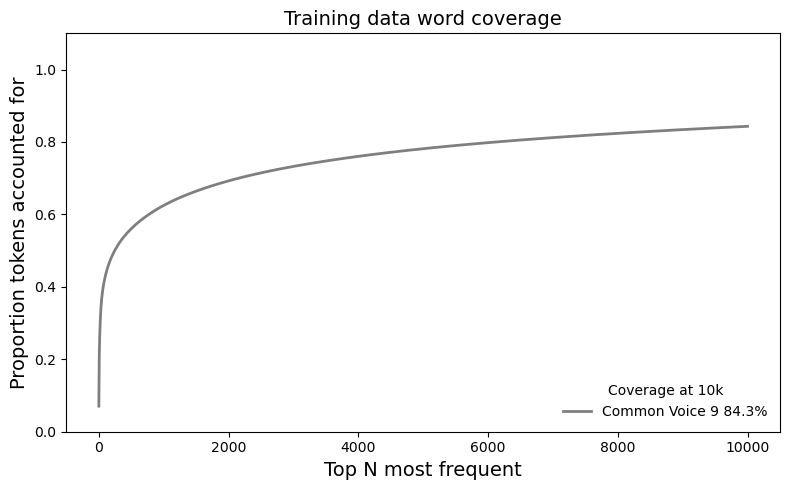

In [33]:
cutoff = 10000
fontsize = 14

words, counts = zip(*word_freq.most_common(cutoff))

cum_prop = np.cumsum(counts) / total_tokens



plt.figure(figsize=(8,5))
plt.plot(cum_prop, 'k', alpha=0.5, linewidth=2,
         label=f"Common Voice 9 {(cum_prop[-1] * 100).round(1)}%")


plt.ylim(0,1.1)
plt.legend(frameon=False, loc='lower right', title='Coverage at 10k')
plt.title("Training data word coverage", fontsize=fontsize)
plt.xlabel("Top N most frequent",fontsize=fontsize)
plt.ylabel("Proportion tokens accounted for",fontsize=fontsize)
plt.tight_layout()


In [36]:
## get frequency of vocab words

# NOTE: need to make words uppercase 
vocab_counts = {word: word_freq[word] for word in vocab}
# sort by frequency
vocab_counts = dict(sorted(vocab_counts.items(), reverse=True, key=lambda item: item[1]))

In [37]:
vocab_words, vocab_word_freq = zip(*vocab_counts.items())

Text(0, 0.5, 'Examples of each token')

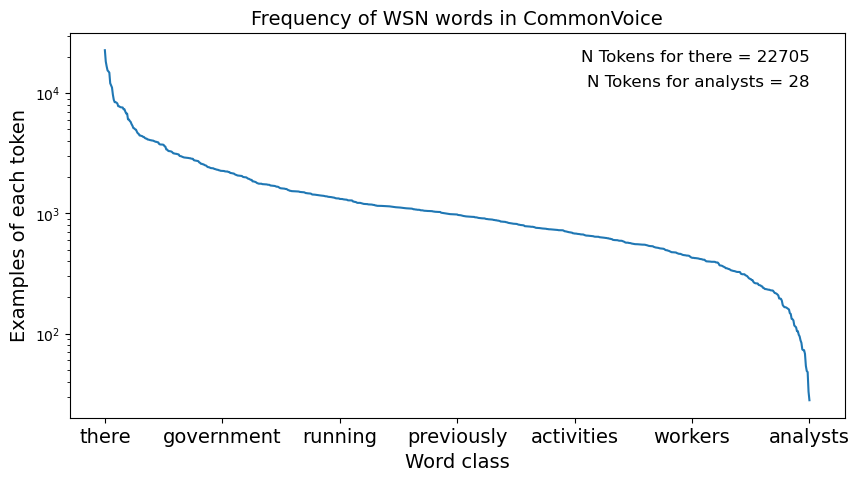

In [38]:
fontsize = 14


plt.figure(figsize=(10,5))
plt.plot(vocab_word_freq)

x_ticks = np.linspace(0,792, 7, dtype=np.int32)
# plt.ylim(0,1.1)
plt.yscale('log')
# plt.legend(frameon=False, loc='upper right',
#            title=)
# plt.ylim(1e1,1e6)
plt.text(792, max(vocab_word_freq) * 0.8,
         f'N Tokens for {vocab_words[0]} = {vocab_word_freq[0]}',
        ha = 'right', fontsize=fontsize - 2)
plt.text(792, max(vocab_word_freq) * 0.5,
         f'N Tokens for {vocab_words[-1]} = {vocab_word_freq[-1]}',
        ha = 'right', fontsize=fontsize - 2)
plt.title("Frequency of WSN words in CommonVoice",fontsize=fontsize)
plt.xticks(x_ticks, np.array(vocab_words)[x_ticks], size=fontsize)
plt.xlabel("Word class",fontsize=fontsize)
plt.ylabel("Examples of each token",fontsize=fontsize)
# plt.ylim(0,10000)
# plt.tight_layout()



In [39]:
all_counts = valid_df.client_id.value_counts()
talkers, counts = all_counts.index, all_counts.values

In [51]:
len(all_counts[all_counts > 50])

2650

Text(0.5, 1.0, 'Talker frequency in Commonvoice')

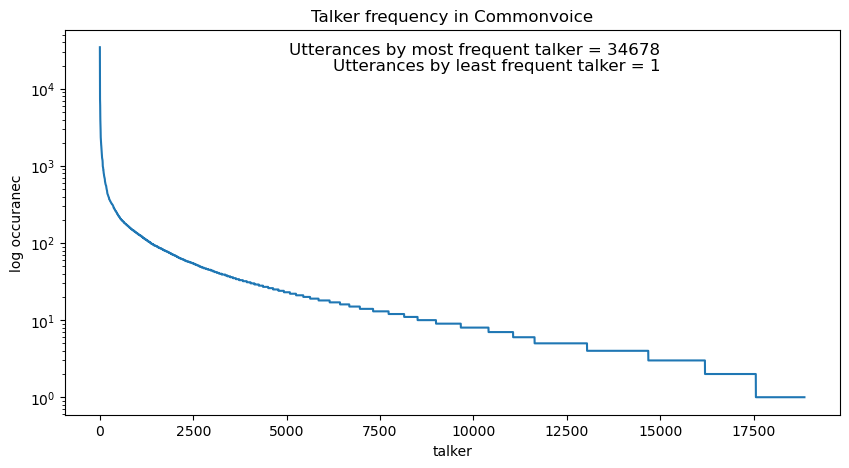

In [48]:
plt.figure(figsize=(10,5))
fontsize = 14


plt.plot(counts)

plt.text(15000, max(counts) * 0.8,
         f'Utterances by most frequent talker = {counts[0]}',
        ha = 'right', fontsize=fontsize - 2)
plt.text(15000, max(counts) * 0.5,
         f'Utterances by least frequent talker = {counts[-1]}',
        ha = 'right', fontsize=fontsize - 2)


plt.yscale('log')
plt.xlabel('talker')
plt.ylabel('log occuranec')
plt.title('Talker frequency in Commonvoice')

In [42]:
len(valid_df.client_id.unique())

18861

In [43]:
len(valid_df)

804369

## Cut to match relative balence in WSN

In [60]:
# copy limits from WSN 
min_talker_count = 51
max_talker_count = 2000

valid_talkers = all_counts[(all_counts >= min_talker_count) & (all_counts <= max_talker_count)]
print("N talkers after screen: ", len(valid_talkers))

compat_df = valid_df[valid_df.client_id.isin(valid_talkers.index)].reset_index(drop=True)
print("N sentences after screen: ", len(compat_df))

N talkers after screen:  2618
N sentences after screen:  457394


In [61]:
## Get word counts 
word_freq = Counter()

compat_df['sentence'].str.lower().apply(lambda x: word_freq.update(x.split()))

total_vocab = len(word_freq)
total_tokens = sum(word_freq.values())

print(f"Combined vocab size is {total_vocab} with {total_tokens} tokens")



Combined vocab size is 237465 with 4634442 tokens


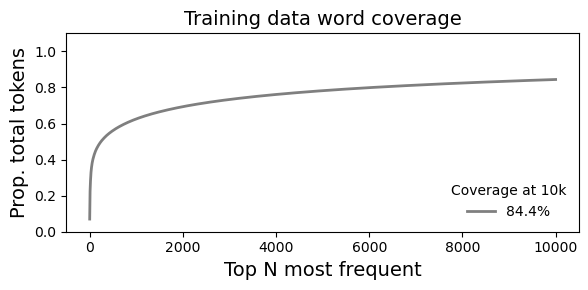

In [64]:
cutoff = 10000
fontsize = 14

words, counts = zip(*word_freq.most_common(cutoff))

cum_prop = np.cumsum(counts) / total_tokens



plt.figure(figsize=(6,3))
plt.plot(cum_prop, 'k', alpha=0.5, linewidth=2,
         label=f"{(cum_prop[-1] * 100).round(1)}%")


plt.ylim(0,1.1)
plt.legend(frameon=False, loc='lower right', title='Coverage at 10k')
plt.title("Training data word coverage", fontsize=fontsize)
plt.xlabel("Top N most frequent",fontsize=fontsize)
plt.ylabel("Prop. total tokens",fontsize=fontsize)
plt.tight_layout()


In [66]:
## get frequency of vocab words

# NOTE: need to make words uppercase 
vocab_counts = {word: word_freq[word] for word in vocab}
# sort by frequency
vocab_counts = dict(sorted(vocab_counts.items(), reverse=True, key=lambda item: item[1]))
vocab_words, vocab_word_freq = zip(*vocab_counts.items())

Text(0, 0.5, 'Examples of each token')

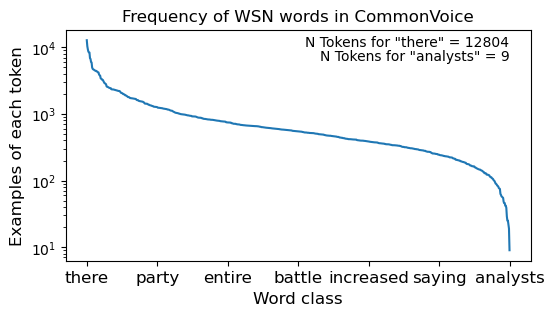

In [77]:
fontsize = 12


plt.figure(figsize=(6,3))
plt.plot(vocab_word_freq)

x_ticks = np.linspace(0,792, 7, dtype=np.int32)
# plt.ylim(0,1.1)
plt.yscale('log')
# plt.legend(frameon=False, loc='upper right',
#            title=)
# plt.ylim(1e1,1e6)
plt.text(792, max(vocab_word_freq) * 0.8,
         f'N Tokens for "{vocab_words[0]}" = {vocab_word_freq[0]}',
        ha = 'right', fontsize=fontsize - 2)
plt.text(792, max(vocab_word_freq) * 0.5,
         f'N Tokens for "{vocab_words[-1]}" = {vocab_word_freq[-1]}',
        ha = 'right', fontsize=fontsize - 2)
plt.title("Frequency of WSN words in CommonVoice",fontsize=fontsize)
plt.xticks(x_ticks, np.array(vocab_words)[x_ticks], size=fontsize)
plt.xlabel("Word class",fontsize=fontsize)
plt.ylabel("Examples of each token",fontsize=fontsize)
# plt.ylim(0,10000)
# plt.tight_layout()



(12804,
 10386,
 9331,
 8611,
 8436,
 8378,
 6879,
 6694,
 6027,
 5953,
 4995,
 4766,
 4675,
 4637,
 4559,
 4505,
 4466,
 4461,
 4368,
 4363,
 4290,
 4226,
 4199,
 3907,
 3816,
 3777,
 3431,
 3376,
 3339,
 3249,
 3247,
 3125,
 3034,
 2916,
 2888,
 2834,
 2804,
 2606,
 2557,
 2556,
 2524,
 2499,
 2468,
 2459,
 2438,
 2435,
 2356,
 2340,
 2338,
 2335,
 2332,
 2320,
 2311,
 2294,
 2280,
 2265,
 2264,
 2254,
 2234,
 2216,
 2213,
 2211,
 2190,
 2132,
 2083,
 2065,
 2057,
 2037,
 1988,
 1986,
 1963,
 1947,
 1902,
 1900,
 1884,
 1855,
 1837,
 1796,
 1791,
 1788,
 1767,
 1735,
 1731,
 1730,
 1724,
 1718,
 1712,
 1704,
 1698,
 1694,
 1689,
 1684,
 1678,
 1637,
 1616,
 1615,
 1614,
 1582,
 1566,
 1561,
 1555,
 1554,
 1546,
 1542,
 1533,
 1526,
 1505,
 1493,
 1455,
 1430,
 1430,
 1428,
 1425,
 1425,
 1402,
 1390,
 1389,
 1363,
 1356,
 1350,
 1337,
 1335,
 1322,
 1318,
 1311,
 1290,
 1284,
 1282,
 1280,
 1279,
 1275,
 1272,
 1264,
 1243,
 1242,
 1239,
 1236,
 1232,
 1231,
 1226,
 1225,
 1220,
 121